In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
df = pd.read_csv('Yemen_Rainfall_1982_2025.csv')
df

,Unnamed: 0,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version,month,dekad,year
0,454320,1982-01-01,2,32878,0,24.0,1.000000,1.043055,4.000000,3.880556,9.833333,14.137500,99.287520,101.34500,77.509250,final,1,1,1982
1,478770,1982-01-01,2,32893,1,19.0,1.157895,1.049123,4.157895,4.145614,9.263158,13.300000,101.798140,100.13426,77.940760,final,1,1,1982
2,455950,1982-01-01,2,32879,2,10.0,1.000000,1.023333,4.000000,4.253334,9.400000,12.836667,99.612610,97.26224,80.732574,final,1,1,1982
3,457580,1982-01-01,2,32880,3,9.0,1.000000,1.003704,4.000000,4.166666,9.888889,13.162963,99.938310,98.18182,81.973900,final,1,1,1982
4,464100,1982-01-01,2,32884,4,6.0,1.000000,1.055556,4.000000,4.094444,10.000000,13.688889,99.082570,98.96152,80.261600,final,1,1,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503707,277333,2025-12-21,2,145040,313,7.0,2.000000,1.652381,4.285714,4.523809,12.142858,17.409523,105.225480,97.50000,76.498085,final,12,21,2025
503708,273655,2025-12-21,2,145039,314,9.0,2.000000,1.600000,4.000000,4.322222,12.444444,17.692593,106.060616,96.54351,76.872850,final,12,21,2025
503709,292463,2025-12-21,2,999528,315,10.0,1.800000,1.570000,4.600000,4.146667,17.800000,21.576668,103.500770,104.95627,85.789530,final,12,21,2025
503710,228307,2025-12-21,2,145016,316,88.0,14.522727,14.787121,34.545456,41.764393,58.613636,74.689390,98.663810,84.56318,79.826980,final,12,21,2025


In [4]:
df = df.drop(['Unnamed: 0', 'adm_level', 'adm_id','rfq','n_pixels','r1q', 'r3q','r1h_avg','rfh_avg','r3h_avg','version'], axis=1, errors='ignore')

df = df.sort_values(by=['PCODE', 'date','year','month','dekad']).reset_index(drop=True)

df.head()

,date,PCODE,rfh,r1h,r3h,month,dekad,year
0,1982-01-01,0,1.000000,4.000000,9.833333,1,1,1982
1,1982-01-11,0,3.000000,6.000000,12.000000,1,11,1982
2,1982-01-21,0,1.000000,5.000000,12.000000,1,21,1982
3,1982-02-01,0,1.000000,5.000000,12.000000,2,1,1982
4,1982-02-11,0,3.583333,5.583333,14.583333,2,11,1982


In [5]:
 # Cyclical month encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dekad_sin'] = np.sin(2 * np.pi * df['dekad']/3)
df['dekad_cos'] = np.cos(2 * np.pi * df['dekad']/3)
df['rfh_lag1'] = df['rfh'].shift(1)
df['rfh_lag2'] = df['rfh'].shift(2)
df['rfh_lag3'] = df['rfh'].shift(3)

In [6]:
df = df.dropna()

In [7]:

# STEP 1: Log Transform First (On original skewed data)

df['rfh'] = np.log1p(df['rfh'])
df['r1h'] = np.log1p(df['r1h'])
df['r3h'] = np.log1p(df['r3h'])


num_features = [
    'rfh','r1h','r3h',
    'month_sin','month_cos',
    'dekad_sin','dekad_cos',
    'rfh_lag1', 'rfh_lag2', 'rfh_lag3'
]
cat_feature = 'PCODE'

scaler = MinMaxScaler()
df[num_features] = scaler.fit_transform(df[num_features])
num_pcodes = df['PCODE'].nunique()


# STEP 3: Split into Train/Val/Test (Use .copy() to avoid warnings)

train_df = df[df['date'] <= '2015-12-31'].copy()
val_df   = df[(df['date'] > '2015-12-31') & (df['date'] <= '2020-12-31')].copy()
test_df  = df[df['date'] > '2020-12-31'].copy()

In [8]:
def create_sequences(df, num_features, cat_feature, window=36):
    X_num, X_cat, y = [], [], []

    for pcode in df[cat_feature].unique():
        df_sub = df[df[cat_feature] == pcode]

        num_data = df_sub[num_features].values
        cat_data = df_sub[cat_feature].values

        for i in range(len(num_data) - window):
            X_num.append(num_data[i:i+window])
            X_cat.append(cat_data[i:i+window])
            y.append(num_data[i+window][0])  # predict rfh

    return np.array(X_num), np.array(X_cat), np.array(y)

In [9]:
X_train_num, X_train_cat, y_train = create_sequences(train_df, num_features, cat_feature)
X_val_num, X_val_cat, y_val = create_sequences(val_df, num_features, cat_feature)
X_test_num, X_test_cat, y_test = create_sequences(test_df, num_features, cat_feature)

In [10]:
def to_loader(X_num, X_cat, y, batch_size=64):
    dataset = TensorDataset(
        torch.tensor(X_num, dtype=torch.float32),
        torch.tensor(X_cat, dtype=torch.long),   # categorical
        torch.tensor(y, dtype=torch.float32)
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, num_features, num_pcodes, embed_dim, hidden_size, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(num_pcodes, embed_dim)

        self.lstm = nn.LSTM(
            input_size=num_features + embed_dim,   
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x_num, x_cat):

        x_cat = self.embedding(x_cat)        # (B, T, embed_dim)

        x = torch.cat([x_num, x_cat], dim=-1)

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        return self.fc(out).squeeze()

In [12]:
def objective(trial):

    hidden_size = trial.suggest_int("hidden_size", 64, 128)
    num_layers  = trial.suggest_int("num_layers", 2, 3)
    dropout     = trial.suggest_float("dropout", 0.1, 0.3)
    lr          = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size  = trial.suggest_categorical("batch_size", [64, 128])
    embed_dim   = trial.suggest_int("embed_dim", 4, 16)

    
    train_loader = to_loader(X_train_num, X_train_cat, y_train, batch_size)
    val_loader   = to_loader(X_val_num, X_val_cat, y_val, batch_size)

    model = LSTMModel(
        num_features=X_train_num.shape[2],
        num_pcodes=num_pcodes,
        embed_dim=embed_dim,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    #  TRAIN
    for epoch in range(30):
        model.train()

        for xb_num, xb_cat, yb in train_loader:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)
            yb     = yb.to(device)

            optimizer.zero_grad()

            pred = model(xb_num, xb_cat)
            loss = loss_fn(pred, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

    #  VALIDATION
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for xb_num, xb_cat, yb in val_loader:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)
            yb     = yb.to(device)

            pred = model(xb_num, xb_cat)

            preds.extend(pred.cpu().numpy())
            actuals.extend(yb.cpu().numpy())

    mse = mean_squared_error(actuals, preds)

    return mse

In [13]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best Params:", study.best_params)

[I 2026-06-06 04:58:47,539] A new study created in memory with name: no-name-9c3d0772-5a14-4850-9156-ca47967018e4
[I 2026-06-06 05:11:03,537] Trial 0 finished with value: 0.009012797847390175 and parameters: {'hidden_size': 105, 'num_layers': 3, 'dropout': 0.15181821738947088, 'lr': 0.001202544624513651, 'batch_size': 64, 'embed_dim': 6}. Best is trial 0 with value: 0.009012797847390175.
[I 2026-06-06 05:21:47,070] Trial 1 finished with value: 0.011231133714318275 and parameters: {'hidden_size': 112, 'num_layers': 2, 'dropout': 0.23015004337027603, 'lr': 0.002804117604513281, 'batch_size': 64, 'embed_dim': 6}. Best is trial 0 with value: 0.009012797847390175.
[I 2026-06-06 05:30:35,880] Trial 2 finished with value: 0.010699570178985596 and parameters: {'hidden_size': 106, 'num_layers': 3, 'dropout': 0.2655889404442632, 'lr': 0.0001991536594548448, 'batch_size': 128, 'embed_dim': 10}. Best is trial 0 with value: 0.009012797847390175.
[I 2026-06-06 05:42:54,039] Trial 3 finished with val

Best Params: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.10176858994542096, 'lr': 0.00010737661600059535, 'batch_size': 128, 'embed_dim': 16}


In [14]:
best = study.best_params

model = LSTMModel(
    num_features=X_train_num.shape[2],
    num_pcodes=num_pcodes,
    embed_dim=best['embed_dim'],
    hidden_size=best['hidden_size'],
    num_layers=best['num_layers'],
    dropout=best['dropout']
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best['lr'])
loss_fn = nn.MSELoss()

train_loader = to_loader(X_train_num, X_train_cat, y_train, best['batch_size'])
val_loader   = to_loader(X_val_num, X_val_cat, y_val, best['batch_size'])
test_loader  = to_loader(X_test_num, X_test_cat, y_test, best['batch_size'])

In [15]:
best_val_loss = float('inf')

for epoch in range(50):

    model.train()
    train_loss = 0

    for xb_num, xb_cat, yb in train_loader:
        xb_num = xb_num.to(device)
        xb_cat = xb_cat.to(device)
        yb     = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb_num, xb_cat)
        loss = loss_fn(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb_num, xb_cat, yb in val_loader:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)
            yb     = yb.to(device)

            pred = model(xb_num, xb_cat)
            loss = loss_fn(pred, yb)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_multi_lstm.pth")

Epoch 1: Train=0.0221, Val=0.0254
Epoch 2: Train=0.0142, Val=0.0169
Epoch 3: Train=0.0100, Val=0.0132
Epoch 4: Train=0.0088, Val=0.0116
Epoch 5: Train=0.0081, Val=0.0111
Epoch 6: Train=0.0076, Val=0.0109
Epoch 7: Train=0.0073, Val=0.0103
Epoch 8: Train=0.0071, Val=0.0102
Epoch 9: Train=0.0070, Val=0.0102
Epoch 10: Train=0.0068, Val=0.0103
Epoch 11: Train=0.0067, Val=0.0104
Epoch 12: Train=0.0067, Val=0.0103
Epoch 13: Train=0.0066, Val=0.0101
Epoch 14: Train=0.0065, Val=0.0099
Epoch 15: Train=0.0064, Val=0.0099
Epoch 16: Train=0.0063, Val=0.0095
Epoch 17: Train=0.0063, Val=0.0095
Epoch 18: Train=0.0062, Val=0.0093
Epoch 19: Train=0.0061, Val=0.0089
Epoch 20: Train=0.0060, Val=0.0089
Epoch 21: Train=0.0060, Val=0.0087
Epoch 22: Train=0.0059, Val=0.0087
Epoch 23: Train=0.0058, Val=0.0086
Epoch 24: Train=0.0058, Val=0.0086
Epoch 25: Train=0.0057, Val=0.0085
Epoch 26: Train=0.0057, Val=0.0084
Epoch 27: Train=0.0056, Val=0.0084
Epoch 28: Train=0.0055, Val=0.0084
Epoch 29: Train=0.0055, Val=0

In [16]:
model.load_state_dict(torch.load("best_model_multi_lstm.pth"))
model.eval()

preds, actuals = [], []

with torch.no_grad():
    for xb_num, xb_cat, yb in test_loader:
        xb_num = xb_num.to(device)
        xb_cat = xb_cat.to(device)
        yb     = yb.to(device)

        pred = model(xb_num, xb_cat)

        preds.extend(pred.cpu().numpy())
        actuals.extend(yb.cpu().numpy())



In [17]:
mse = mean_squared_error(actuals, preds)
mae = mean_absolute_error(actuals, preds)
r2  = r2_score(actuals, preds)

print("MSE:", mse)
print("MAE:", mae)
print("R2 :", r2)

MSE: 0.009525528
MAE: 0.069212936
R2 : 0.7261983635999507


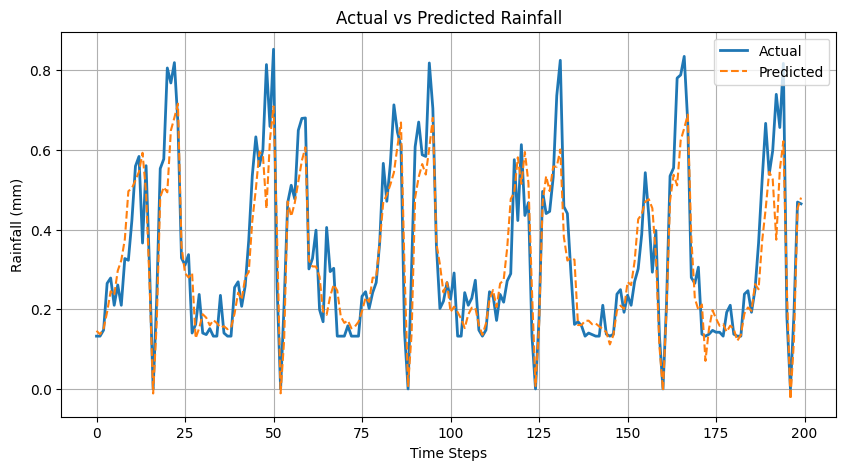

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# plt.plot(actuals[:200], label="Actual")
# plt.plot(preds[:200], label="Predicted")
plt.plot(actuals[:200], label="Actual", linewidth=2)
plt.plot(preds[:200], label="Predicted", linestyle='--')

plt.xlabel("Time Steps")          # X-axis label
plt.ylabel("Rainfall (mm)")       # Y-axis label
plt.title("Actual vs Predicted Rainfall")  # Title

plt.legend()
plt.grid(True)

plt.show()

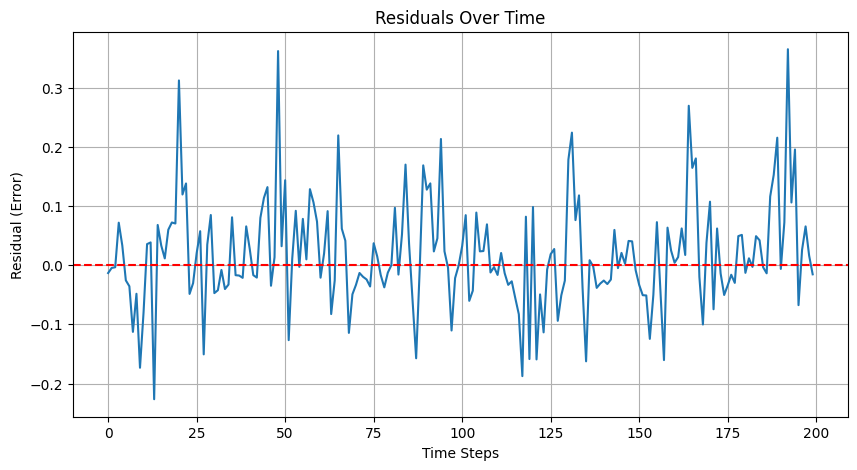

In [19]:
residuals = np.array(actuals) - np.array(preds)

plt.figure(figsize=(10,5))
plt.plot(residuals[:200])

plt.axhline(0, color='r', linestyle='--')  # zero line

plt.xlabel("Time Steps")
plt.ylabel("Residual (Error)")
plt.title("Residuals Over Time")

plt.grid(True)
plt.show()

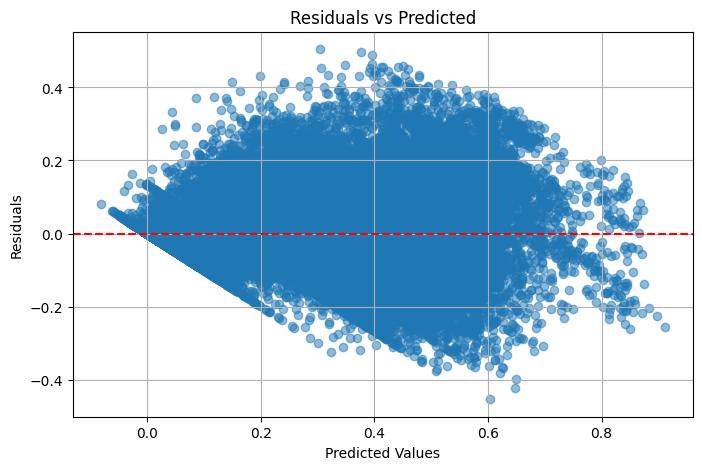

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(preds, residuals, alpha=0.5)

plt.axhline(0, color='r', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.grid(True)
plt.show()

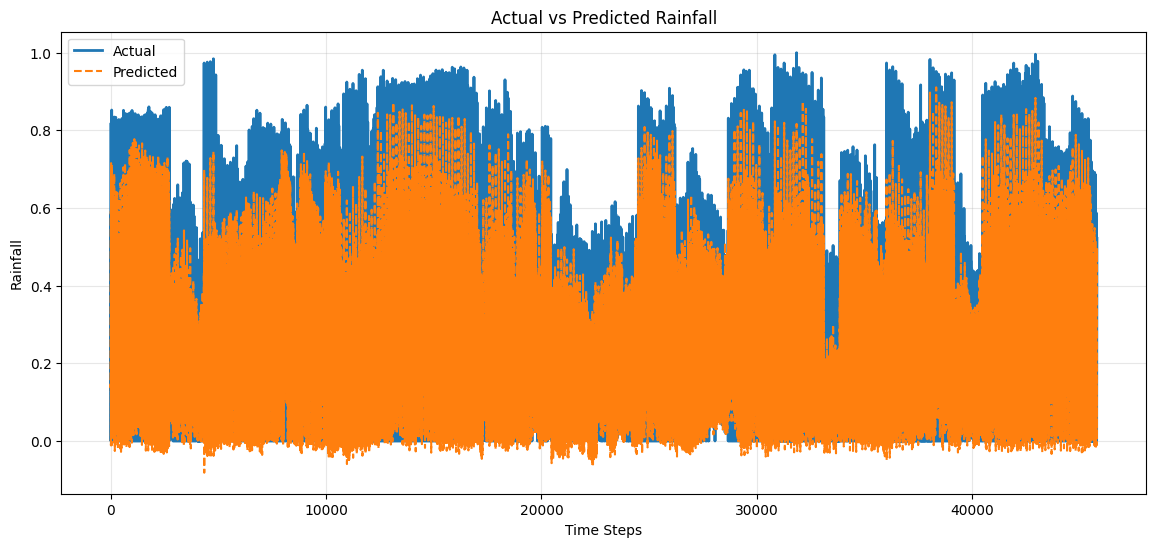

In [21]:
y_true = np.array(actuals).flatten()
y_pred = np.array(preds).flatten()

plt.figure(figsize=(14,6))

plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle='--')

plt.title("Actual vs Predicted Rainfall")
plt.xlabel("Time Steps")
plt.ylabel("Rainfall")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()

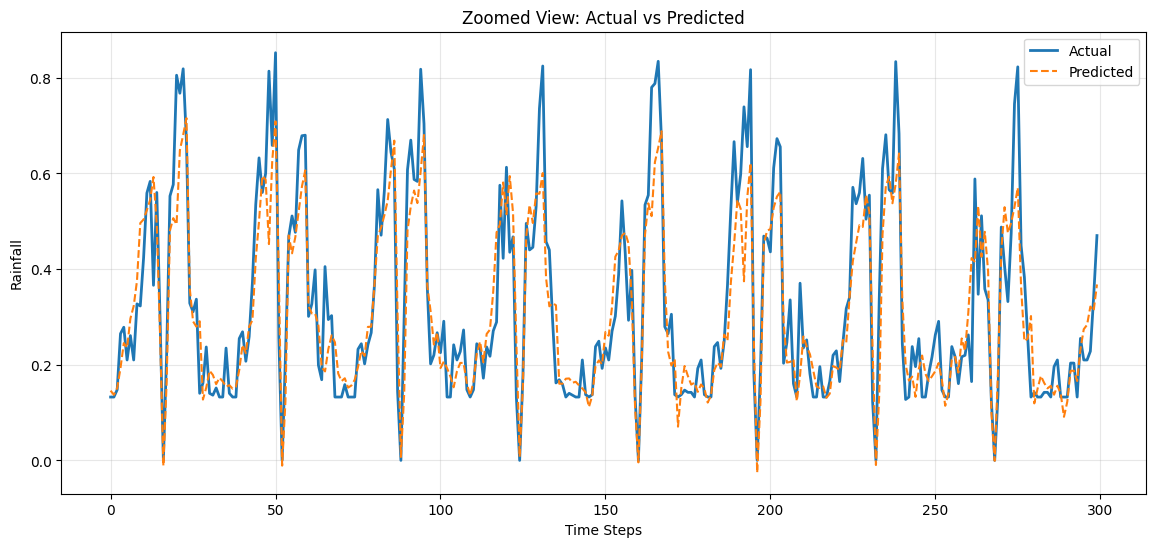

In [22]:
start, end = 0, 300

plt.figure(figsize=(14,6))

plt.plot(y_true[start:end], label="Actual", linewidth=2)
plt.plot(y_pred[start:end], label="Predicted", linestyle='--')

plt.title("Zoomed View: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Rainfall")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig("zoom_plot.png", dpi=300)
plt.show()

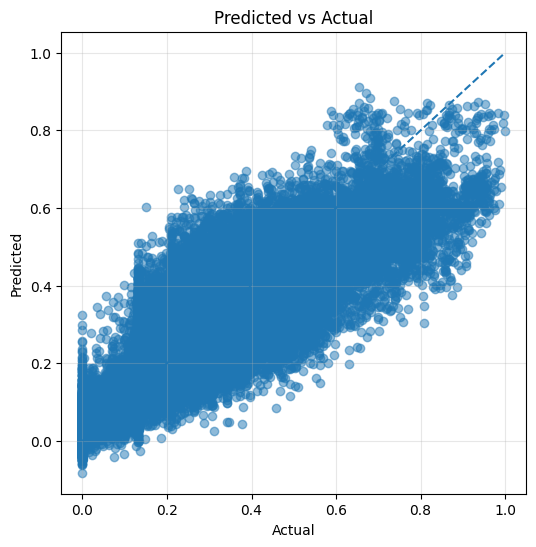

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

# perfect prediction line
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

plt.grid(alpha=0.3)

plt.savefig("scatter_plot_lstm.png", dpi=300)
plt.show()

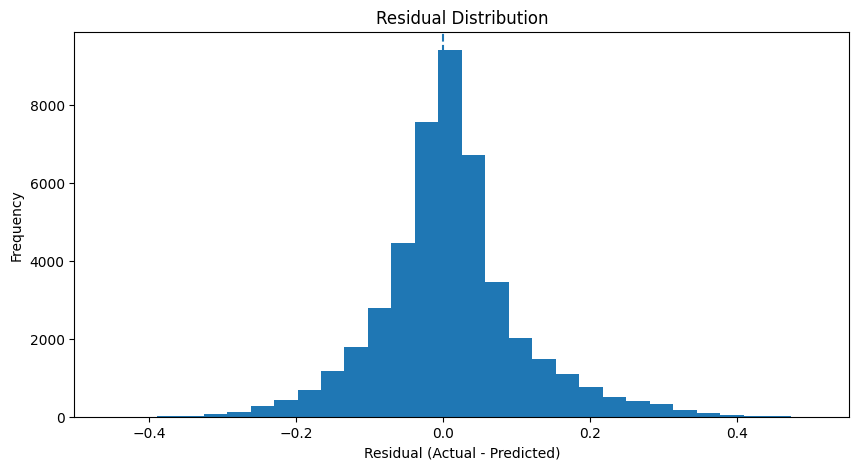

In [24]:
residuals = y_true - y_pred

plt.figure(figsize=(10,5))

plt.hist(residuals, bins=30)
plt.axvline(0, linestyle='--')

plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.savefig("residual_plot.png", dpi=300)
plt.show()

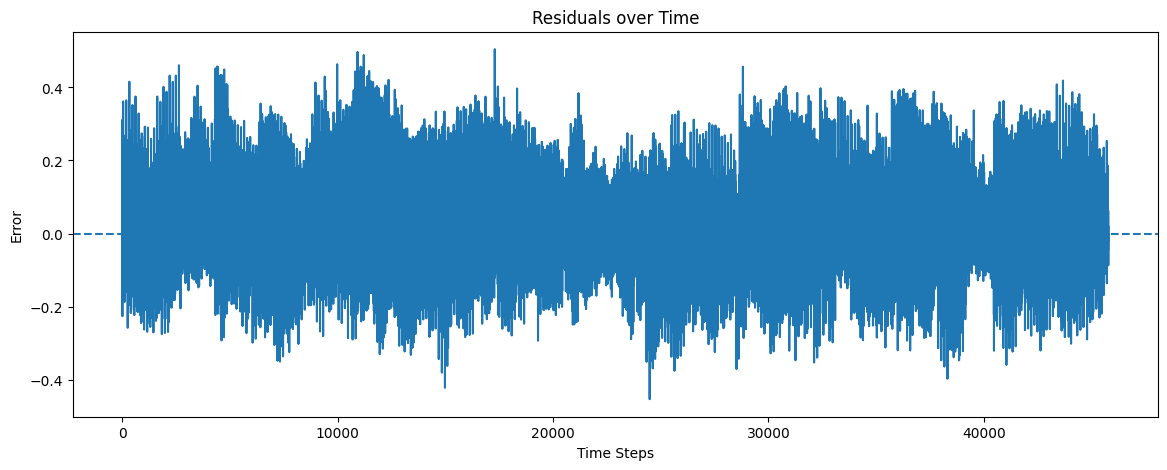

In [25]:
plt.figure(figsize=(14,5))

plt.plot(residuals)

plt.axhline(0, linestyle='--')

plt.title("Residuals over Time")
plt.xlabel("Time Steps")
plt.ylabel("Error")

plt.savefig("residual_time.png", dpi=300)
plt.show()

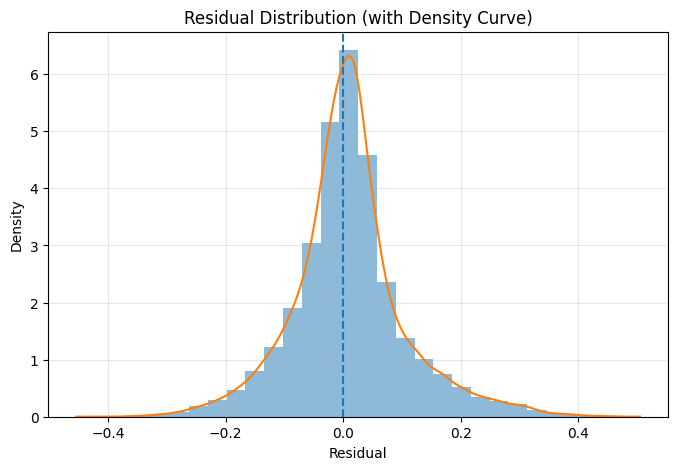

In [26]:
from scipy.stats import gaussian_kde

density = gaussian_kde(residuals)
xs = np.linspace(residuals.min(), residuals.max(), 200)

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30, density=True, alpha=0.5)
plt.plot(xs, density(xs))

plt.axvline(0, linestyle='--')

plt.title("Residual Distribution (with Density Curve)")
plt.xlabel("Residual")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.savefig("residual_distribution_kde.png", dpi=300)
plt.show()

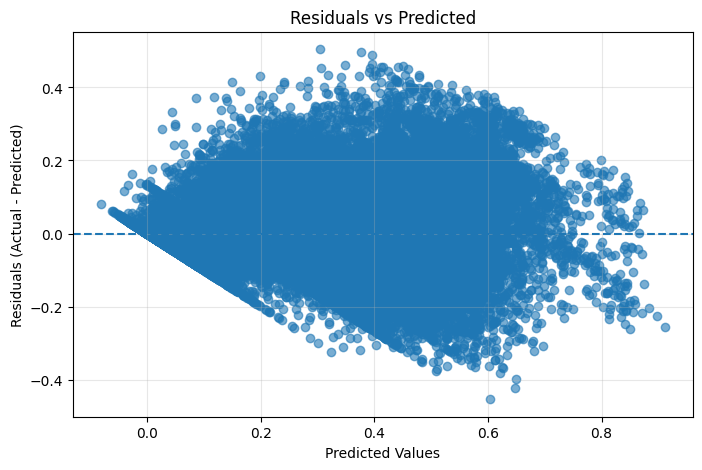

In [27]:
# Convert to numpy
y_true = np.array(actuals).flatten()
y_pred = np.array(preds).flatten()

# Residuals
residuals = y_true - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.6)

# Zero error line
plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")

plt.grid(alpha=0.3)

plt.savefig("residual_vs_predicted.png", dpi=300)
plt.show()

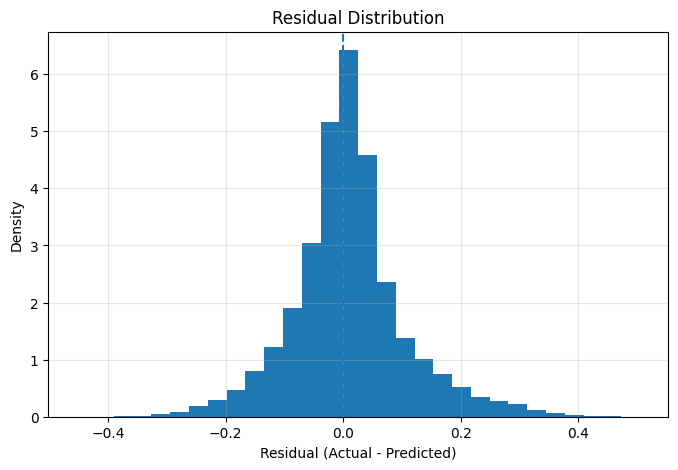

In [28]:
# Convert to numpy
y_true = np.array(actuals).flatten()
y_pred = np.array(preds).flatten()

# Residuals
residuals = y_true - y_pred

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30, density=True)
plt.axvline(0, linestyle='--')

plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.savefig("residual_distribution.png", dpi=300)
plt.show()

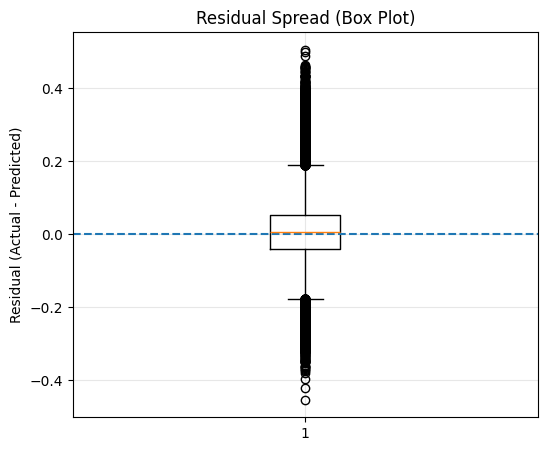

In [29]:
# Convert
y_true = np.array(actuals).flatten()
y_pred = np.array(preds).flatten()

# Residuals
residuals = y_true - y_pred

plt.figure(figsize=(6,5))

plt.boxplot(residuals, vert=True)

# zero reference line
plt.axhline(0, linestyle='--')

plt.title("Residual Spread (Box Plot)")
plt.ylabel("Residual (Actual - Predicted)")

plt.grid(alpha=0.3)

plt.savefig("residual_boxplot.png", dpi=300)
plt.show()

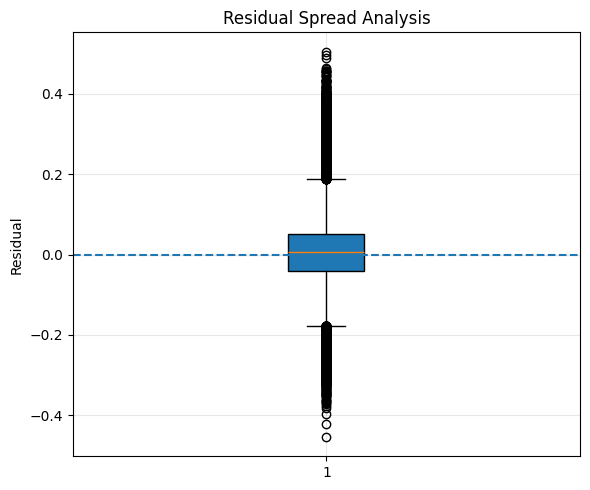

In [30]:
plt.figure(figsize=(6,5))

plt.boxplot(
    residuals,
    vert=True,
    patch_artist=True   # filled box (cleaner look)
)

plt.axhline(0, linestyle='--')

plt.title("Residual Spread Analysis")
plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("residual_boxplot_clean.png", dpi=300)
plt.show()

In [31]:
results = pd.DataFrame({
    "actual": actuals,
    "pred": preds
})

results.to_csv("lstm_results.csv", index=False)

In [32]:
lstm = pd.read_csv("lstm_results.csv")
lstm

,actual,pred
0,0.132476,0.145807
1,0.132476,0.137155
2,0.147774,0.151324
3,0.264952,0.193195
4,0.278403,0.245186
...,...,...
45787,0.351450,0.368511
45788,0.382391,0.407802
45789,0.413690,0.456380
45790,0.487883,0.494562
